In [5]:
import pandas as pd
from wcwidth import width

In [6]:
df=pd.read_csv('../data/processed/final.csv')

In [7]:
print(df.columns)
print(df.shape)
print(df.head(10))

Index(['time', 'BIOMASS', 'CCGT', 'COAL', 'INTELE', 'INTELEC', 'INTEW',
       'INTFR', 'INTGRNL', 'INTIFA2', 'INTIRL', 'INTNED', 'INTNEM', 'INTNSL',
       'INTVKL', 'NPSHYD', 'NUCLEAR', 'OCGT', 'OIL', 'OTHER', 'PS', 'WIND',
       'demand', 'demand_prediction', 'error', 'error_abs', 'temperature_2m',
       'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION',
       'PUMP_STORAGE_PUMPING', 'IFA_FLOW', 'BRITNED_FLOW', 'NEMO_FLOW',
       'NSL_FLOW', 'SystemSellPrice', 'SystemBuyPrice', 'NetImbalanceVolume',
       'TotalAcceptedOfferVolume', 'TotalAcceptedBidVolume'],
      dtype='str')
(87491, 39)
                  time  BIOMASS     CCGT    COAL  INTELE  INTELEC  INTEW  \
0  2016-01-08 01:00:00      0.0  10571.5  3792.5     0.0      0.0  286.0   
1  2016-01-08 02:00:00      0.0  10067.0  3884.5     0.0      0.0  169.0   
2  2016-01-08 03:00:00      0.0  10167.5  3865.5     0.0      0.0   39.0   
3  2016-01-08 04:00:00      0.0  10169.5  3985.0     0.0      0.0   64.0   
4  2016-0

In [8]:
#built splike
df['rolling_month']=df['SystemSellPrice'].shift(1).rolling(30*24).quantile(0.75)

df['is_spike']=(df['SystemSellPrice']>df['rolling_month']).astype(int)

print(df.groupby('is_spike')[['error_abs','CCGT','WIND','NetImbalanceVolume','PS']].mean())
print(df['is_spike'].mean())

           error_abs          CCGT         WIND  NetImbalanceVolume  \
is_spike                                                              
0         187.207792  10938.305301  5980.785030         -144.568651   
1         211.426527  13888.539872  5021.176964          255.894711   

                  PS  
is_spike              
0        -189.850656  
1         255.481394  
0.2577065069550011


In [9]:
#another way to build splike
threshold=df['SystemSellPrice'].quantile(0.75)
df['is_spike_static']=(df['SystemSellPrice']>threshold).astype(int)
print(df.groupby('is_spike_static')[['error_abs','CCGT','WIND','NetImbalanceVolume','PS']].mean())
df=df.drop(columns=['is_spike_static'])

                  error_abs          CCGT         WIND  NetImbalanceVolume  \
is_spike_static                                                              
0                182.981812  11336.363231  5561.252880         -106.152391   
1                224.850557  12785.293535  6250.184634          152.987664   

                         PS  
is_spike_static              
0               -146.720839  
1                139.816486  


clearly first one is better

In [10]:
# df['rolling_month_2']=df['SystemSellPrice'].shift(1).rolling(30*24).quantile(0.90)
# df['is_spike_soft']=((df['SystemSellPrice']>df['rolling_month'])&(df['SystemSellPrice']<df['rolling_month_2'])).astype(int)

In [11]:
df['ccgt_wind_ratio']=(df['CCGT']/df['WIND']+1)
df['imbalance_ccgt']=(df['NetImbalanceVolume']*df['CCGT'])
df['ps_imbalance']=df['PS']*df['NetImbalanceVolume']
df['offer_bid_spread']=df['TotalAcceptedOfferVolume']-df['TotalAcceptedBidVolume']

In [12]:
df['time']=pd.to_datetime(df['time'])
df['month']=df['time'].dt.month
distribution_spike=df.groupby('month')['is_spike'].mean()
print(distribution_spike)
print(distribution_spike.sort_values(ascending=False))

month
1     0.214610
2     0.171084
3     0.250706
4     0.232500
5     0.250975
6     0.308750
7     0.253563
8     0.304611
9     0.289861
10    0.243614
11    0.295777
12    0.271004
Name: is_spike, dtype: float64
month
6     0.308750
8     0.304611
11    0.295777
9     0.289861
12    0.271004
7     0.253563
5     0.250975
3     0.250706
10    0.243614
4     0.232500
1     0.214610
2     0.171084
Name: is_spike, dtype: float64


When the temperature is lower, more easily see the price splike.

In [13]:
import matplotlib.pyplot as plt

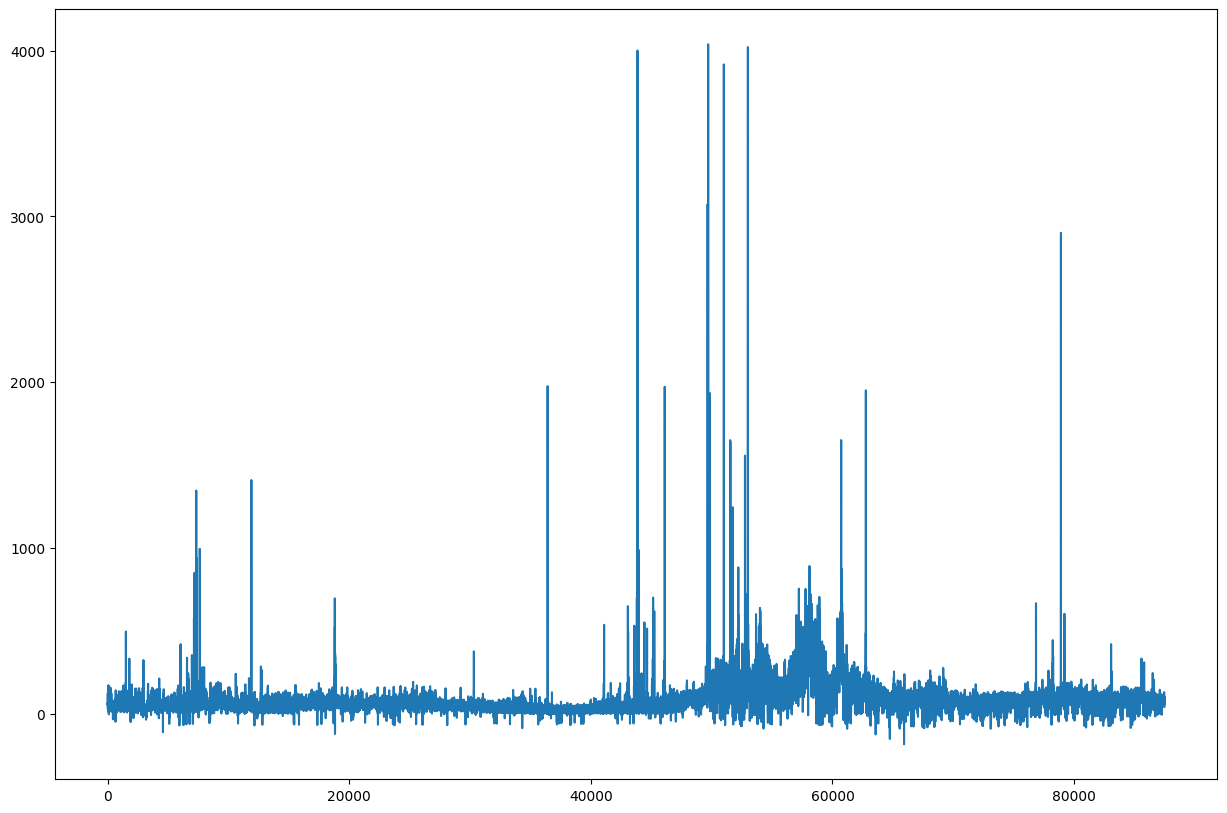

In [14]:
#EDA
plt.figure(figsize=(15,10))
plt.plot(df['SystemSellPrice'].values)
plt.show()

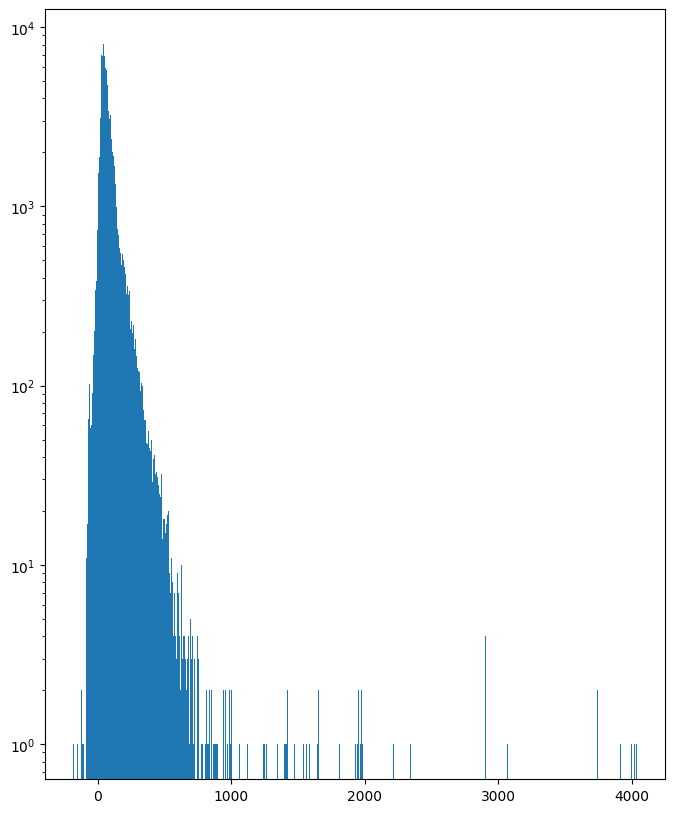

In [15]:
plt.figure(figsize=(8,10))
plt.hist(df['SystemSellPrice'],bins='auto',log=True)
plt.show()

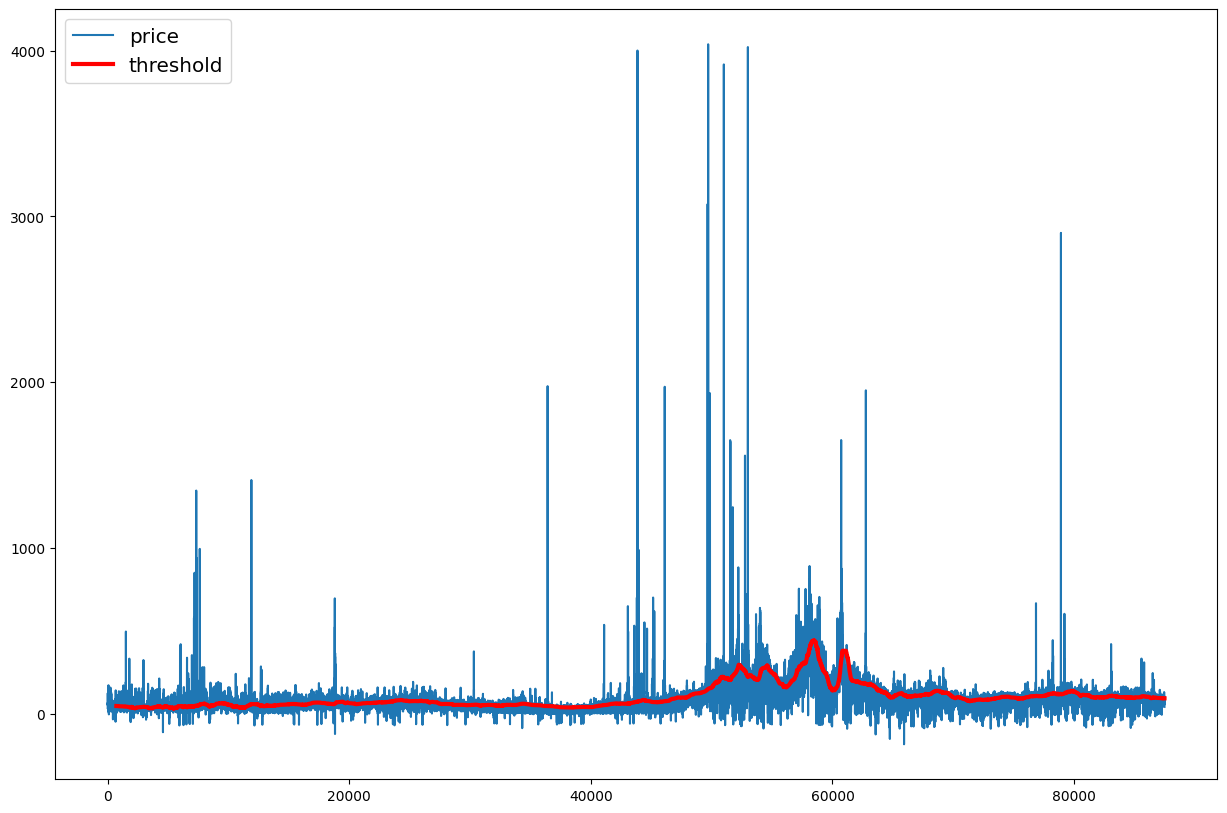

<Figure size 1500x1000 with 0 Axes>

In [16]:
plt.figure(figsize=(15,10))
plt.plot(df['SystemSellPrice'].values,label='price')
plt.plot(df['rolling_month'].values,'r',linewidth=3,label='threshold')
plt.legend(fontsize='x-large',loc='upper left')
plt.show()
plt.figure(figsize=(15,10))
plt.show()

In [17]:
# cols = ['CCGT','WIND','NetImbalanceVolume','PS']
# for col in cols:
#     plt.figure(figsize=(15,18))
#     df.boxplot(column=col,by='is_splike',grid=True)
#     plt.show()
#
# df['log_error']=np.log1p(df['error_abs'])
# plt.figure(figsize=(15,10))
# df.boxplot(column='log_error',by='is_splike')
# plt.show()
#
# df=df.drop(columns=['log_error'])

In [18]:
from src.features.classification_var_choose import class_var_choose

In [19]:
eda_list=df.columns.tolist()
# print(eda_list)
eda_list.remove('time')
eda_list.remove('rolling_month')
eda_list.remove('is_spike')
eda_list.remove('INTELE')
print(eda_list)

importance=class_var_choose(eda_list,df,'is_spike')
print(importance)

['BIOMASS', 'CCGT', 'COAL', 'INTELEC', 'INTEW', 'INTFR', 'INTGRNL', 'INTIFA2', 'INTIRL', 'INTNED', 'INTNEM', 'INTNSL', 'INTVKL', 'NPSHYD', 'NUCLEAR', 'OCGT', 'OIL', 'OTHER', 'PS', 'WIND', 'demand', 'demand_prediction', 'error', 'error_abs', 'temperature_2m', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION', 'PUMP_STORAGE_PUMPING', 'IFA_FLOW', 'BRITNED_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'SystemSellPrice', 'SystemBuyPrice', 'NetImbalanceVolume', 'TotalAcceptedOfferVolume', 'TotalAcceptedBidVolume', 'ccgt_wind_ratio', 'imbalance_ccgt', 'ps_imbalance', 'offer_bid_spread', 'month']
                          var     score
38             imbalance_ccgt  0.741285
34         NetImbalanceVolume  0.691622
32            SystemSellPrice  0.542928
33             SystemBuyPrice  0.542928
18                         PS  0.375110
36     TotalAcceptedBidVolume  0.342618
1                        CCGT  0.275007
37            ccgt_wind_ratio  0.209055
39               ps_imbalance  0.206604
13          

In [20]:
keep_col=[ 'CCGT', 'COAL','INTEW', 'INTFR', 'INTIRL', 'INTNED', 'NPSHYD', 'OCGT','OTHER', 'PS', 'WIND', 'demand_prediction','NetImbalanceVolume', 'TotalAcceptedBidVolume', 'ccgt_wind_ratio', 'imbalance_ccgt', 'ps_imbalance', 'offer_bid_spread', 'month','is_spike','PUMP_STORAGE_PUMPING','TotalAcceptedOfferVolume','time']
small_df=df[keep_col]

In [21]:
from src.extract.save_dir import saved_data_dir

In [22]:
saved_data_dir('model_dataset.csv',small_df,'../data/processed/')

model_dataset.csv saved to C:\Users\24363\Desktop\powering_market_forecasting_analytics\data\processed\model_dataset.csv
